# Personalized News Recommendation System

This project builds a hybrid recommendation system using:
- Content-based filtering
- Collaborative filtering

The system recommends personalized news articles based on user interests and interaction history.


In [3]:
!pip install scikit-surprise

In [4]:
from google.colab import files

uploaded = files.upload()

Saving interactions.csv to interactions.csv
Saving news.csv to news.csv


In [7]:
!pip uninstall numpy -y
!pip install numpy==1.26.4
!pip install scikit-surprise

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 whi

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split

In [2]:
news_df = pd.read_csv("news.csv")
interactions_df = pd.read_csv("interactions.csv")

print(news_df)
print(interactions_df)

   article_id                 title       category  \
0           1      AI in Healthcare     Technology   
1           2            IPL Finals         Sports   
2           3    Stock Market Crash        Finance   
3           4     New Movie Release  Entertainment   
4           5  SpaceX Rocket Launch     Technology   
5           6    Football World Cup         Sports   

                                             content  
0  Artificial intelligence is transforming health...  
1         The IPL finals were exciting and thrilling  
2     Stock market crashed due to inflation concerns  
3           A new action movie released this weekend  
4            SpaceX launched a new rocket into space  
5             World cup matches are becoming intense  
   user_id  article_id  rating
0      101           1       1
1      101           5       1
2      101           2       1
3      102           2       1
4      102           6       1
5      103           3       1
6      103         

In [3]:
news_df['text'] = (
    news_df['title'] + " " +
    news_df['category'] + " " +
    news_df['content']
)

print(news_df['text'])

0    AI in Healthcare Technology Artificial intelli...
1    IPL Finals Sports The IPL finals were exciting...
2    Stock Market Crash Finance Stock market crashe...
3    New Movie Release Entertainment A new action m...
4    SpaceX Rocket Launch Technology SpaceX launche...
5    Football World Cup Sports World cup matches ar...
Name: text, dtype: object


# Content-Based Filtering

TF-IDF converts article text into numerical vectors.

Cosine similarity helps identify articles with similar content.

In [4]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(news_df['text'])

print(tfidf_matrix.shape)

(6, 36)


In [5]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(cosine_sim)

[[1.         0.         0.         0.         0.06153644 0.        ]
 [0.         1.         0.         0.         0.         0.06024636]
 [0.         0.         1.         0.         0.         0.        ]
 [0.         0.         0.         1.         0.11195112 0.        ]
 [0.06153644 0.         0.         0.11195112 1.         0.        ]
 [0.         0.06024636 0.         0.         0.         1.        ]]


In [6]:
indices = pd.Series(news_df.index, index=news_df['article_id'])

def get_similar_articles(article_id, top_n=5):

    idx = indices[article_id]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n+1]

    article_indices = [i[0] for i in sim_scores]

    return news_df.iloc[article_indices][['article_id', 'title']]

In [7]:
print(get_similar_articles(1))

   article_id                 title
4           5  SpaceX Rocket Launch
1           2            IPL Finals
2           3    Stock Market Crash
3           4     New Movie Release
5           6    Football World Cup


# Collaborative Filtering

Collaborative filtering predicts user preferences based on interaction history.

The SVD model is used from the Surprise library.


In [8]:
reader = Reader(rating_scale=(0, 1))

data = Dataset.load_from_df(
    interactions_df[['user_id', 'article_id', 'rating']],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2
)

model = SVD()

model.fit(trainset)

In [9]:
prediction = model.predict(101, 3)

print(prediction.est)

0.9462886652452418


# Hybrid Recommendation System

This system combines:
- Content-based filtering
- Collaborative filtering

Final recommendations are generated using weighted scores from both methods.

In [10]:
def hybrid_recommendation(user_id, top_n=5, alpha=0.7):

    user_articles = interactions_df[
        interactions_df['user_id'] == user_id
    ]['article_id'].tolist()

    scores = {}

    for article_id in news_df['article_id']:

        if article_id in user_articles:
            continue

        collaborative_score = model.predict(
            user_id,
            article_id
        ).est

        content_score = 0

        for read_article in user_articles:

            idx1 = indices[article_id]
            idx2 = indices[read_article]

            content_score += cosine_sim[idx1][idx2]

        if len(user_articles) > 0:
            content_score /= len(user_articles)

        final_score = (
            alpha * collaborative_score +
            (1 - alpha) * content_score
        )

        scores[article_id] = final_score

    recommended = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    result = []

    for article_id, score in recommended:

        title = news_df[
            news_df['article_id'] == article_id
        ]['title'].values[0]

        result.append((article_id, title, score))

    return result

In [11]:
recommendations = hybrid_recommendation(101)

for rec in recommendations:
    print(rec)

(4, 'New Movie Release', 0.6699189325076915)
(3, 'Stock Market Crash', 0.6624020656716693)
(6, 'Football World Cup', 0.6413295044255781)


In [12]:
def precision_at_k(recommended, relevant, k):

    recommended_k = recommended[:k]

    relevant_set = set(relevant)

    recommended_set = set(recommended_k)

    precision = len(
        recommended_set.intersection(relevant_set)
    ) / k

    return precision

In [13]:
recommendations = hybrid_recommendation(101)

print("Recommended Articles:\n")

for rec in recommendations:
    print(rec)

Recommended Articles:

(4, 'New Movie Release', 0.6699189325076915)
(3, 'Stock Market Crash', 0.6624020656716693)
(6, 'Football World Cup', 0.6413295044255781)


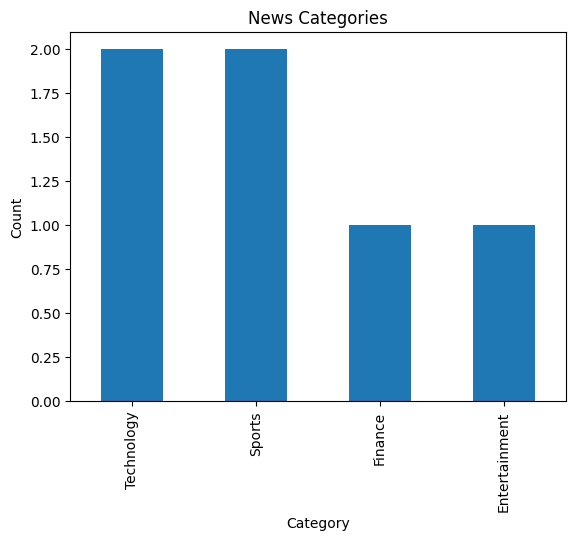

In [14]:
import matplotlib.pyplot as plt

news_df['category'].value_counts().plot(kind='bar')

plt.title("News Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

# Conclusion

This project successfully demonstrates a hybrid recommendation engine using machine learning and NLP techniques.

The system provides personalized news recommendations using user behavior and article similarity.